LAB -3 DHANUSH.V 1RUA24SCS0031

Lab 3 Ensemble Learning Boosting

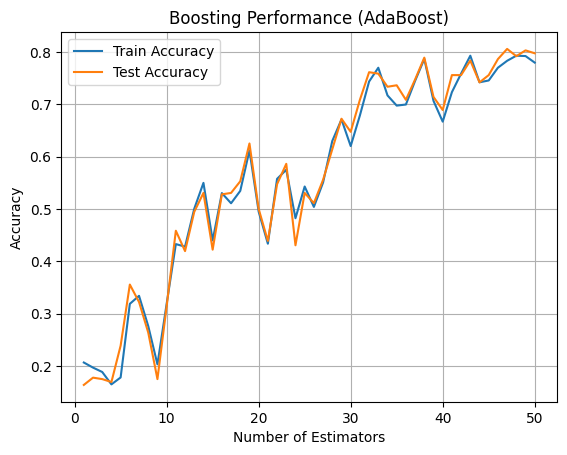

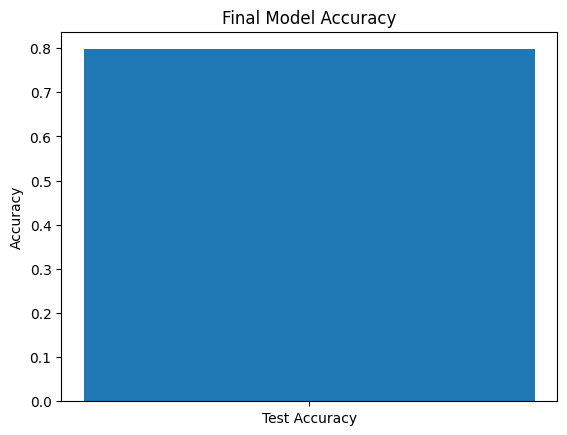

Final Test Accuracy: 0.7972222222222223


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


data = load_digits()
X, y = data.data, data.target


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


base_model = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
    estimator=base_model,  
    n_estimators=50,
    learning_rate=1,
    random_state=42
)


model.fit(X_train, y_train)


estimators_range = range(1, 51)
train_scores = []
test_scores = []

for n in estimators_range:
    temp_model = AdaBoostClassifier(
        estimator=base_model,   
        n_estimators=n,
        learning_rate=1,
        random_state=42
    )

    temp_model.fit(X_train, y_train)

    train_scores.append(temp_model.score(X_train, y_train))
    test_scores.append(temp_model.score(X_test, y_test))


plt.figure()
plt.plot(estimators_range, train_scores, label='Train Accuracy')
plt.plot(estimators_range, test_scores, label='Test Accuracy')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Boosting Performance (AdaBoost)")
plt.legend()
plt.grid()
plt.show()


final_accuracy = model.score(X_test, y_test)

plt.figure()
plt.bar(['Test Accuracy'], [final_accuracy])
plt.title("Final Model Accuracy")
plt.ylabel("Accuracy")
plt.show()


print("Final Test Accuracy:", final_accuracy)